## Simulation experiment 0
2026-05-04

Motivation: 
Experiment 1 is struggling to stay upright. 

Objective: 
See whether or not the RL agent can keep the drone steady

Stats: 
M249_saw
No wind
No target

In [3]:
import argparse
import time
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

from drone_sim.control.controller import quat_to_euler, wrap_pi
from drone_sim.rl.custom_envs import ZeroTargetEnv

import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

import torch

In [4]:
# Loading model to continue training
model = PPO.load("ppo_e0_thrust", env = ZeroTargetEnv(control_level='thrust'), learning_rate=5e-6, ent_coef=0.01, target_kl=0.01)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [4]:
model = PPO.load("../experiment-1/ppo_e-1_bc_hover2", env=ZeroTargetEnv(control_level='thrust'))
# Force std down if it drifted up during PPO fine-tuning
with torch.no_grad():
    model.policy.log_std.fill_(-2.0)
model.learn(total_timesteps=500_000)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | 415      |
| time/              |          |
|    fps             | 1557     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 500         |
|    ep_rew_mean          | 417         |
| time/                   |             |
|    fps                  | 956         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.017545093 |
|    clip_fraction        | 0.211       |
|    clip_range           | 0.2         |
|    entropy_loss         | 2.92        |
|    explained_variance   | 0.751       |
|    learning_rate        | 0.

In [11]:

# policy_kwargs forces std = e^-2 ≈ 0.135 instead of the default std=1.
# With std=1 the policy can survive by "jiggling" randomly without learning real
# state-dependent corrections, so deterministic=True fails. Low std forces the
# mean to be a proper feedback controller.
vec_env = make_vec_env(lambda: ZeroTargetEnv(control_level='thrust'), n_envs=4)

model = PPO(
    "MlpPolicy", vec_env,
    policy_kwargs={'log_std_init': -2.0},
    verbose=1,
)
model.learn(total_timesteps=1_000_000, reset_num_timesteps=False)
model.save("ppo_e0_thrust")


Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40.8     |
|    ep_rew_mean     | -73.6    |
| time/              |          |
|    fps             | 1457     |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 8192     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 39.8        |
|    ep_rew_mean          | -47.3       |
| time/                   |             |
|    fps                  | 851         |
|    iterations           | 2           |
|    time_elapsed         | 19          |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.024468705 |
|    clip_fraction        | 0.292       |
|    clip_range           | 0.2         |
|    entropy_loss         | 2.89        |
|    explained_variance   | 0.00351     |
|    learning

KeyboardInterrupt: 

In [ ]:
vec_env = make_vec_env(lambda: ZeroTargetEnv(control_level='thrust', render_mode='human'))

model = PPO.load("ppo_e0_thrust")

obs = vec_env.reset()
for i in range(400):
    action, _states = model.predict(obs)
    obs, rewards, dones, info = vec_env.step(action)
    vec_env.render("human")

In [5]:
def run_episode(env, model, render: bool = False, print_every: int = 20):
    """Run one full episode, print rolling reward, return per-step rewards."""
    obs, info = env.reset()
    rewards = []
    cum = 0.0
    if render:
        env.render()

    print(f"{'step':>5}  {'reward':>8}  {'cum':>10}  {'hits':>5}  {'ammo':>4}")
    print("-" * 44)
    while True:
        action = model.predict(obs, deterministic=True)[0]
        obs, r, terminated, truncated, info = env.step(action)
        rewards.append(float(r))
        cum += r
        if render:
            env.render()

        step = len(rewards)
        if step % print_every == 0 or terminated or truncated:
            print(f"{step:5d}  {r:+8.2f}  {cum:+10.2f}  "
                  f"{info['cumulative_hits']:5d}  {info['ammo']:4d}")

        if terminated or truncated:
            print("-" * 44)
            print(f"end: terminated={terminated} truncated={truncated} "
                  f"final cumulative reward = {cum:+.2f}")
            break

    return np.asarray(rewards, dtype=float)


def plot_rewards(rewards: np.ndarray, save_path: str = "pid_agent_reward.png"):
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(rewards, linewidth=0.8)
    ax[0].set_ylabel("reward / step")
    ax[0].grid(True, alpha=0.3)
    ax[0].axhline(0.0, color="black", linewidth=0.5)

    ax[1].plot(np.cumsum(rewards), color="C1")
    ax[1].set_xlabel("env step")
    ax[1].set_ylabel("cumulative reward")
    ax[1].grid(True, alpha=0.3)
    ax[1].axhline(0.0, color="black", linewidth=0.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    print(f"plot saved to {save_path}")


 step    reward         cum   hits  ammo
--------------------------------------------
   20     -0.57      +10.11      0    30
   40    -10.69      -76.94      0    25
   43    -26.68     -133.15      0    25
--------------------------------------------
end: terminated=True truncated=False final cumulative reward = -133.15
plot saved to pid_agent_reward.png


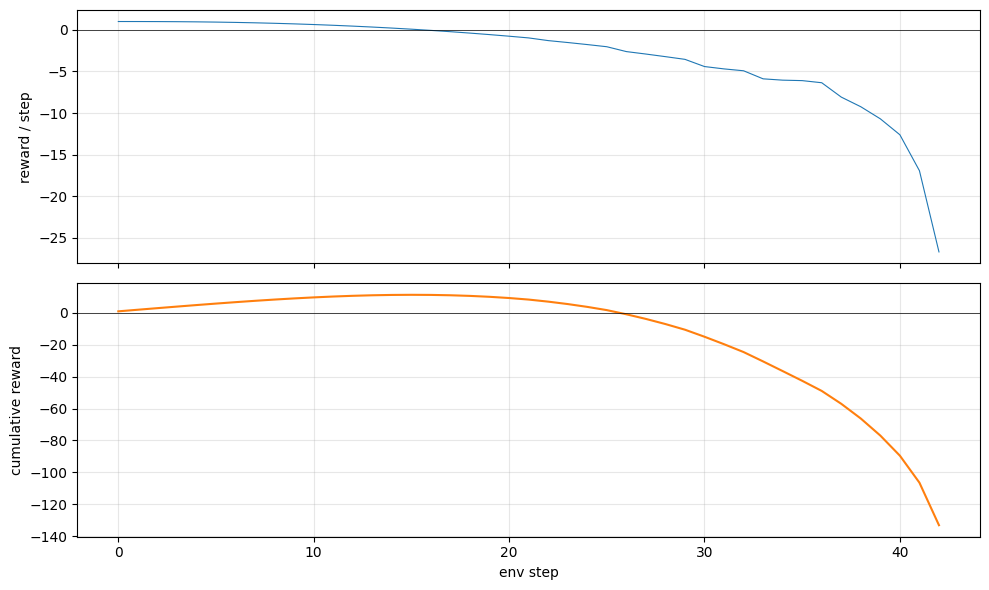

In [ ]:
#env = ZeroTargetEnv(
#    n_targets=0,
#    target_height=1.5,
#    seed=100,
#    max_episode_steps=1000,
#    render_mode="human",
#)

rewards = run_episode(env, model, render=True)
env.close()

plot_rewards(rewards)